# Week 10 - Restful Web Services
#### Part 2
### Notebook created by Jonathan Penava
By the end of this lesson you should know the steps to add Restful Web Services to a ML application.

## Overview
- Flask and Postman Setup
- <span style="color:red;">Get and Post</span>
- Consuming Web Services
- Web Service with ML

In [7]:
from flask import Flask, request, jsonify
app = Flask(__name__)

If postman is up and working for you, we are going to try to send and receive information.  Starting with a list of student records we are going to want to either add to our list, or get our list.

In [8]:
students = [
    {"id": 1, "name": "Jash", "grade": 88, "letterGrade": "A"},
    {"id": 2, "name": "Dhruv", "grade": 77, "letterGrade": "B"},
    {"id": 3, "name": "Yatik", "grade": 66, "letterGrade": "C"}
]

If we are going to add to our list we want to identify the next available index.

In [9]:
#Create an id for the student at the next index.
def _find_next_id():
    return max(stu["id"] for stu in students) + 1

We identify the url http://127.0.0.1:5000/students as a GET request to return our collection of students.  When we send our information it will usually be a string.  In this case we want to send a student collection so we convert our collection into a JSON string to preserve a key value pair of values which is our records.

In [10]:
@app.get("/students")
def get_students():
    return jsonify(students)

We identify the url http://127.0.0.1:5000/students as a POST request to accept a new student record.  That new record will come in as a JSON record.

In [11]:
@app.post("/students")
def add_student():
    if request.is_json:
        stu = request.get_json() #Get the JSON from postman.
        stu["id"] = _find_next_id() #Assign the id to the student.
        students.append(stu) #Add student to the collection.
        return stu #Return the student with the assigned id.
    return {"error": "Request must be JSON"}

In [12]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


Testing out our get request

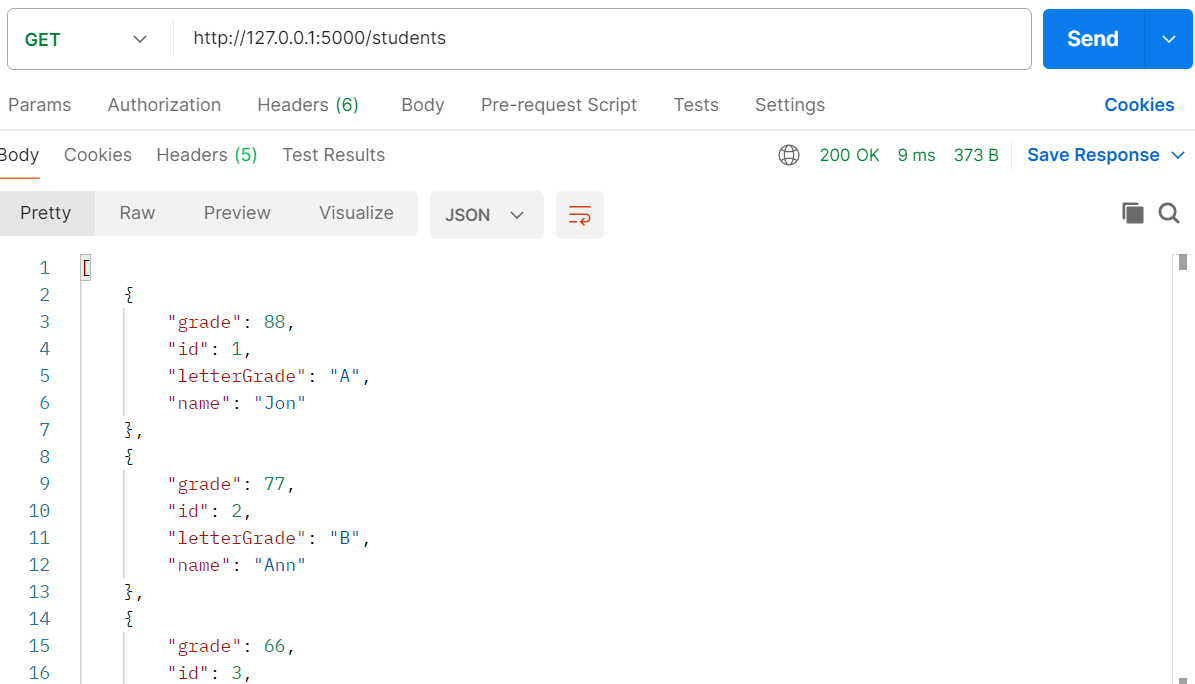

When we test out our post request, we need to create a JSON record.  Notice the areas that are circled to change.

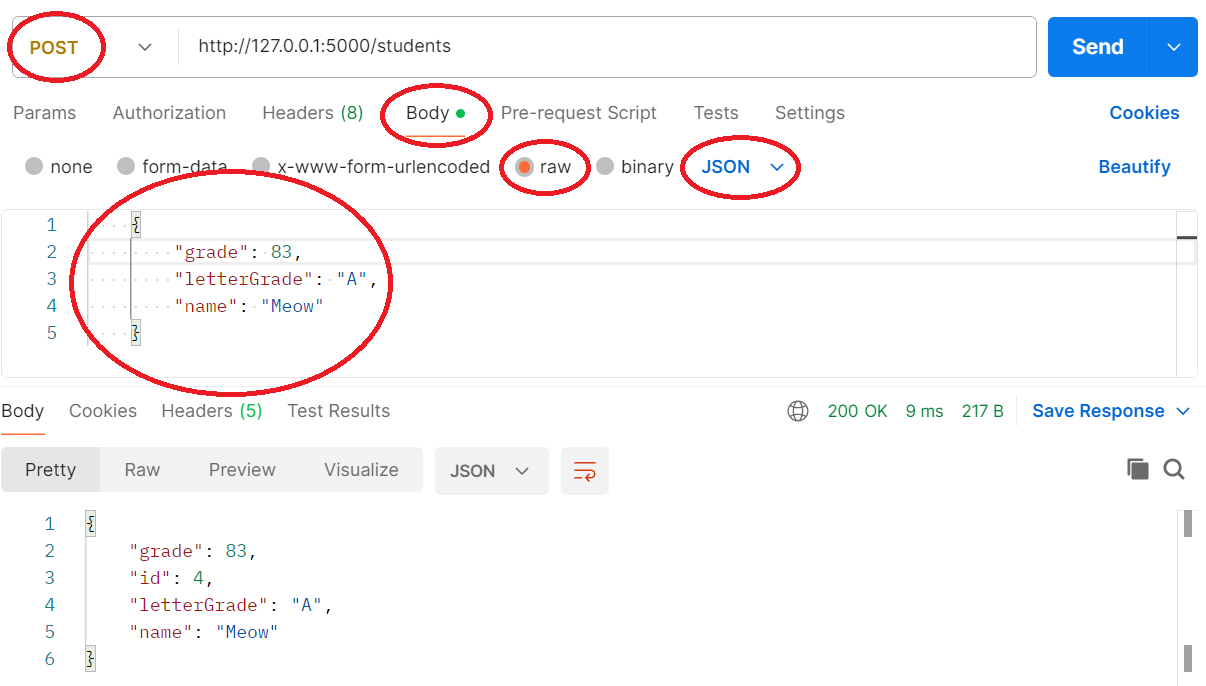